In [1]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

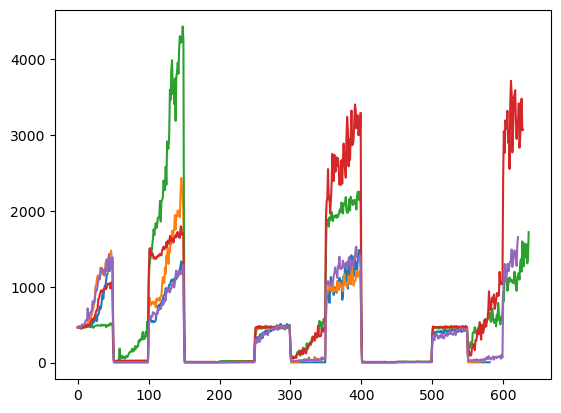

In [7]:
results0 = pd.read_csv('./results/cw/ppo_0.csv')
results1 = pd.read_csv('./results/cw/ppo_1.csv')
results2 = pd.read_csv('./results/cw/ppo_2.csv')
results3 = pd.read_csv('./results/cw/ppo_3.csv')
results4 = pd.read_csv('./results/cw/ppo_4.csv')

plt.plot(results0['Metrics/EpRet'])
plt.plot(results1['Metrics/EpRet'])
plt.plot(results2['Metrics/EpRet'])
plt.plot(results3['Metrics/EpRet'])
plt.plot(results4['Metrics/EpRet'])

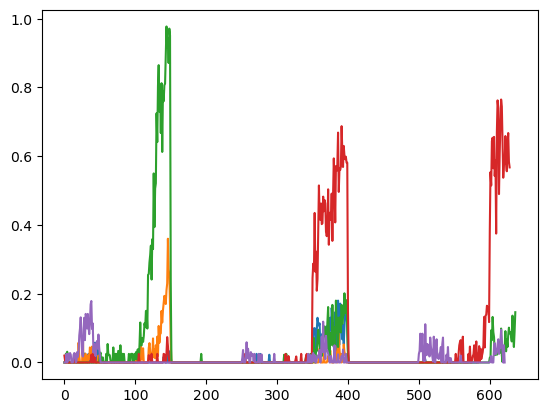

In [8]:
results0 = pd.read_csv('./results/cw/ppo_0.csv')
results1 = pd.read_csv('./results/cw/ppo_1.csv')
results2 = pd.read_csv('./results/cw/ppo_2.csv')
results3 = pd.read_csv('./results/cw/ppo_3.csv')
results4 = pd.read_csv('./results/cw/ppo_4.csv')

plt.plot(results0['Metrics/EpSuccess'])
plt.plot(results1['Metrics/EpSuccess'])
plt.plot(results2['Metrics/EpSuccess'])
plt.plot(results3['Metrics/EpSuccess'])
plt.plot(results4['Metrics/EpSuccess'])

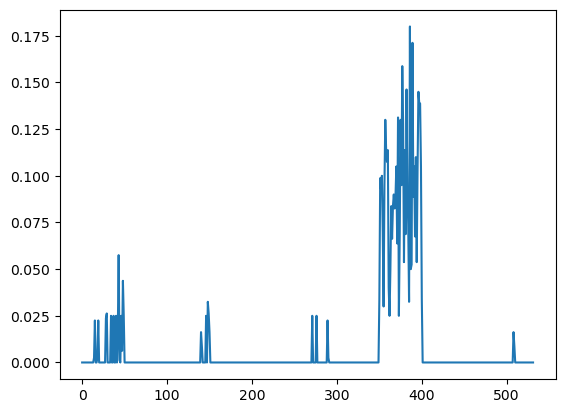

In [5]:
plt.plot(results['Metrics/EpSuccess'])

Done
Cheetah - PPO, CPO, CPPO_PID, PPO_Lag
In progress - PPO_EWC, CLEAR
TODO - PPO_EWC_COST, CLEAR_COST?

CW - PPO, CPO, CPPO_PID, PPO_LAG, PPO_EWC, CLEAR, PPO_EWC_COST

At least 8 more -
4 hours, 7x? hours

4 more sessions

hammer, push-wall, faucet, push-back, stick-pull

# Continual World Results

In [2]:
def aggregate_metrics(results_list, task_sequence, task_length):
    task_names = ['safe-hammer', 'safe-push-wall', 'safe-faucet', 'safe-push-back', 'safe-stick-pull']
    costs, forgets, rewards = {name: [] for name in task_names}, {name: [] for name in task_names}, {name: [] for name in task_names}

    for result in results_list:
        metrics = calculate_metrics(result, task_sequence, task_length, task_names)
        for name in task_names:
            costs[name].append(metrics[f'{name}_cost'])
            forgets[name].append(metrics[f'{name}_forget'])
            rewards[name].append(metrics[f'{name}_reward'])

    print("COSTS:")
    for name in task_names:
        print(f'{name.capitalize()} total costs: {np.mean(costs[name])} +/- {np.std(costs[name])}')

    print("FORGETTING RATIO:")
    for name in task_names:
        print(f'{name.capitalize()} forgetting: {np.mean(forgets[name])} +/- {np.std(forgets[name])}')

    print("REWARDS:")
    for name in task_names:
        print(f'{name.capitalize()} rewards: {np.mean(rewards[name])} +/- {np.std(rewards[name])}')

def calculate_metrics(results, task_sequence, task_length, task_names):
    results = add_task_names(results, task_sequence, task_length)
    metrics = {}
    for name in task_names:
        metrics[f'{name}_cost'], metrics[f'{name}_forget'], metrics[f'{name}_reward'] = (
            average_total_costs(results, name, task_length),
            forgetting(results, name, task_length),
            rewards(results, name, task_length)
        )
    return metrics

def add_task_names(results, task_sequence, task_length):
    task_names = [[task] * task_length for task in task_sequence]
    task_names = np.concatenate(task_names)
    results['task'] = task_names
    return results

def average_total_costs(results, task_name, task_length):
    task_results = results[results['task'] == task_name]
    task_costs = task_results['Metrics/EpCost'].to_numpy()
    num_visited = int(len(task_costs) / task_length)
    total_costs = [task_costs[np.arange(0, task_length) + i * task_length].sum() for i in range(num_visited)]
    return np.mean(total_costs)

def forgetting(results, task_name, task_length):
    task_results = results[results['task'] == task_name]
    task_rewards = task_results['Metrics/EpRet'].to_numpy()
    endpoint = task_length - 1
    startpoint = task_length + 1
    num_visited = int(len(task_rewards) / task_length)
    num_restart = num_visited - 1
    forget_values = [(task_rewards[endpoint * (i+1)] - task_rewards[startpoint * (i+1)]) / np.abs(task_rewards[endpoint * (i+1)]) * 100 for i in range(num_restart)]
    return np.mean(forget_values)

def rewards(results, task_name, task_length):
    task_results = results[results['task'] == task_name]
    task_rewards = task_results['Metrics/EpRet'].to_numpy()
    endpoint = task_length - 1
    num_visited = int(len(task_rewards) / task_length)
    reward_vals = [task_rewards[endpoint * (i+1)] for i in range(num_visited)]
    return reward_vals[-1]

In [3]:
tasks_encountered = ['safe-hammer', 'safe-push-wall', 'safe-faucet', 'safe-push-back', 'safe-stick-pull',
                     'safe-hammer', 'safe-push-wall', 'safe-faucet', 'safe-push-back', 'safe-stick-pull',
                     'safe-hammer', 'safe-push-wall', 'safe-faucet', 'safe-push-back', 'safe-stick-pull',]


cpo_cw_0 = pd.read_csv('./results/cpo_cw_0.csv')
cpo_cw_1 = pd.read_csv('./results/cpo_cw_1.csv')
cpo_cw_2 = pd.read_csv('./results/cpo_cw_2.csv')
cpo_cw_3 = pd.read_csv('./results/cpo_cw_3.csv')
cpo_cw_4 = pd.read_csv('./results/cpo_cw_4.csv')

cpo_list = [cpo_cw_0, cpo_cw_1, cpo_cw_2, cpo_cw_3, cpo_cw_4]

cw_cpo_rewards = [results['Metrics/EpRet'] for results in cpo_list]
cw_cpo_success = [results['Metrics/EpSuccess'] for results in cpo_list]
cw_cpo_costs = [results['Metrics/EpCost'] for results in cpo_list]

cw_cpo_mean_rewards = np.mean(cw_cpo_rewards, axis=0)
cw_cpo_mean_success = np.mean(cw_cpo_success, axis=0)
cw_cpo_mean_costs = np.mean(cw_cpo_costs, axis=0)

cw_cpo_std_rewards = np.std(cw_cpo_rewards, axis=0)
cw_cpo_std_success = np.std(cw_cpo_success, axis=0)
cw_cpo_std_costs = np.std(cw_cpo_costs, axis=0)

aggregate_metrics(cpo_list, tasks_encountered, 50)

COSTS:
Safe-hammer total costs: 18188.578549898713 +/- 14128.097893645672
Safe-push-wall total costs: 26561.288006387924 +/- 19912.106327274592
Safe-faucet total costs: 33733.9194312779 +/- 41187.056734188576
Safe-push-back total costs: 41919.87252235772 +/- 29978.284758980077
Safe-stick-pull total costs: 25674.03875 +/- 36510.35648059009
FORGETTING RATIO:
Safe-hammer forgetting: 6.817026172309532 +/- 8.248866044709867
Safe-push-wall forgetting: -29.55167644812976 +/- 169.62040951697793
Safe-faucet forgetting: 8.166144862857712 +/- 4.831251947535298
Safe-push-back forgetting: 4.223106578187443 +/- 37.0566230109325
Safe-stick-pull forgetting: -17.38534269917026 +/- 30.636694967456148
REWARDS:
Safe-hammer rewards: 315.0406664477694 +/- 9.924746888354152
Safe-push-wall rewards: 11.630364005245882 +/- 7.865201567036747
Safe-faucet rewards: 1830.2645825883724 +/- 259.6250035666887
Safe-push-back rewards: 3.2510266027711707 +/- 2.8952507787169353
Safe-stick-pull rewards: 10.396934613628734 +

In [4]:
cpo_cw_0['Metrics/EpSuccess'].max()

0.0

In [5]:
cpo_cw_0['task']

0          safe-hammer
1          safe-hammer
2          safe-hammer
3          safe-hammer
4          safe-hammer
            ...       
745    safe-stick-pull
746    safe-stick-pull
747    safe-stick-pull
748    safe-stick-pull
749    safe-stick-pull
Name: task, Length: 750, dtype: object

Text(0.5, 1.0, 'Safe Continual World')

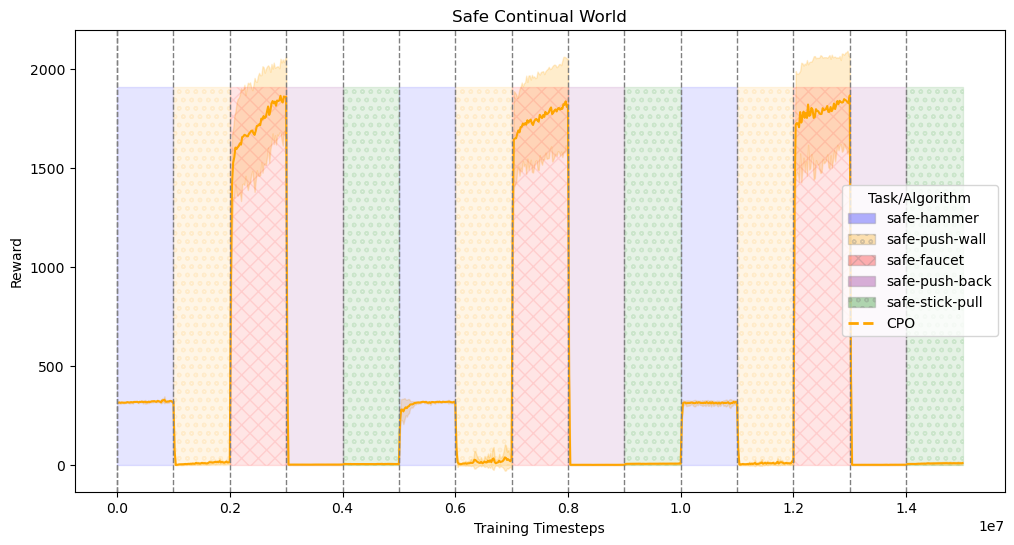

In [6]:
TASK_CYCLE = tasks_encountered
algorithms = ['CPO']
algorithm_colors={'CPO': 'orange'}
cycle_colors = {
    'safe-hammer': 'blue',
    'safe-push-wall': 'orange',
    'safe-faucet': 'red',
    'safe-push-back': 'purple',
    'safe-stick-pull': 'green'
}

cycle_hatches = {
    'safe-hammer': '',
    'safe-push-wall': 'oo',
    'safe-faucet': 'xx',
    'safe-push-back': '',
    'safe-stick-pull': 'oo'
}

plt.figure(figsize=(12,6))
plt.plot(cpo_cw_0['Train/TotalSteps'], cw_cpo_mean_rewards, label='CPO', color='orange')
plt.fill_between(
    cpo_cw_0['Train/TotalSteps'],
    cw_cpo_mean_rewards - cw_cpo_std_rewards,
    cw_cpo_mean_rewards + cw_cpo_std_rewards,
    color='orange', alpha=0.2
)

x_vals = range(0, max(cpo_cw_0['Train/TotalSteps']) + 1, 1000000)
for i, x in enumerate(x_vals[:-1]):  # Exclude the last x-value as it doesn't define a region
    # Get the current task from the cycle
    task = TASK_CYCLE[i % len(TASK_CYCLE)]
    
    # Shade the region between the current and next x value
    plt.axvline(x=x, color='gray', linestyle='--', linewidth=1)
    plt.fill_between([x, x_vals[i + 1]], cpo_cw_0['Metrics/EpRet'].min(), cpo_cw_4['Metrics/EpRet'].max(), color=cycle_colors[task],  hatch=cycle_hatches[task], alpha=0.1)

plt.axvline(x=0, color='gray', linestyle='--', linewidth=1, label='Task Change')

legend_patches = []
for task in cycle_colors:
    patch = mpatches.Patch(
        facecolor=cycle_colors[task], 
        hatch=cycle_hatches[task], 
        label=task,
        edgecolor='gray',  # Optional: add edgecolor to improve visibility in legend,
        alpha=0.3
    )
    legend_patches.append(patch)

for algorithm in algorithms:
    custom_line = Line2D([0], [0], color=algorithm_colors[algorithm], lw=2, linestyle='--', label=algorithm.upper())
    legend_patches.append(custom_line)
# Add legend to the plot
plt.legend(handles=legend_patches, title='Task/Algorithm')

plt.xlabel("Training Timesteps")
plt.ylabel("Reward")
plt.title("Safe Continual World")

Text(0.5, 1.0, 'Safe Continual World')

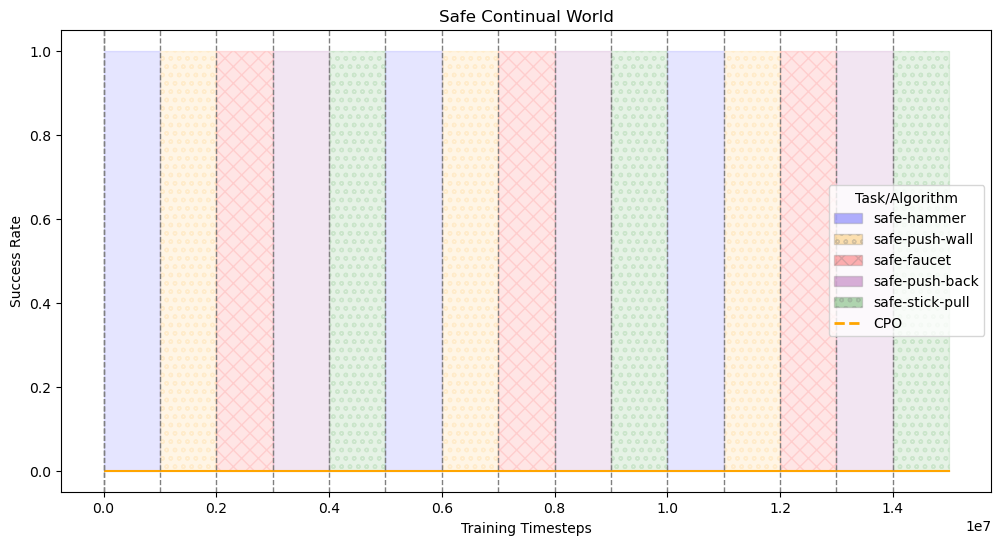

In [7]:
TASK_CYCLE = tasks_encountered
algorithms = ['CPO']
algorithm_colors={'CPO': 'orange'}
cycle_colors = {
    'safe-hammer': 'blue',
    'safe-push-wall': 'orange',
    'safe-faucet': 'red',
    'safe-push-back': 'purple',
    'safe-stick-pull': 'green'
}

cycle_hatches = {
    'safe-hammer': '',
    'safe-push-wall': 'oo',
    'safe-faucet': 'xx',
    'safe-push-back': '',
    'safe-stick-pull': 'oo'
}

plt.figure(figsize=(12,6))
plt.plot(cpo_cw_0['Train/TotalSteps'], cw_cpo_mean_success, label='CPO', color='orange')
plt.fill_between(
    cpo_cw_0['Train/TotalSteps'],
    cw_cpo_mean_success - cw_cpo_std_success,
    cw_cpo_mean_success + cw_cpo_std_success,
    color='orange', alpha=0.2
)

x_vals = range(0, max(cpo_cw_0['Train/TotalSteps']) + 1, 1000000)
for i, x in enumerate(x_vals[:-1]):  # Exclude the last x-value as it doesn't define a region
    # Get the current task from the cycle
    task = TASK_CYCLE[i % len(TASK_CYCLE)]
    
    # Shade the region between the current and next x value
    plt.axvline(x=x, color='gray', linestyle='--', linewidth=1)
    plt.fill_between([x, x_vals[i + 1]], 0, 1, color=cycle_colors[task],  hatch=cycle_hatches[task], alpha=0.1)

plt.axvline(x=0, color='gray', linestyle='--', linewidth=1, label='Task Change')

legend_patches = []
for task in cycle_colors:
    patch = mpatches.Patch(
        facecolor=cycle_colors[task], 
        hatch=cycle_hatches[task], 
        label=task,
        edgecolor='gray',  # Optional: add edgecolor to improve visibility in legend,
        alpha=0.3
    )
    legend_patches.append(patch)

for algorithm in algorithms:
    custom_line = Line2D([0], [0], color=algorithm_colors[algorithm], lw=2, linestyle='--', label=algorithm.upper())
    legend_patches.append(custom_line)
# Add legend to the plot
plt.legend(handles=legend_patches, title='Task/Algorithm')

plt.xlabel("Training Timesteps")
plt.ylabel("Success Rate")
plt.title("Safe Continual World")

Text(0.5, 1.0, 'Safe Continual World')

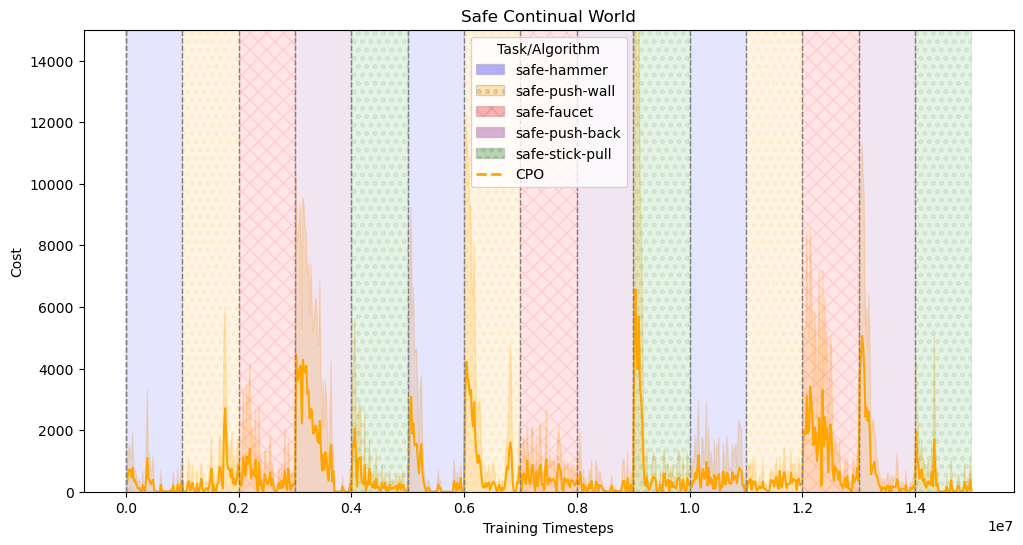

In [15]:
TASK_CYCLE = tasks_encountered
algorithms = ['CPO']
algorithm_colors={'CPO': 'orange'}
cycle_colors = {
    'safe-hammer': 'blue',
    'safe-push-wall': 'orange',
    'safe-faucet': 'red',
    'safe-push-back': 'purple',
    'safe-stick-pull': 'green'
}

cycle_hatches = {
    'safe-hammer': '',
    'safe-push-wall': 'oo',
    'safe-faucet': 'xx',
    'safe-push-back': '',
    'safe-stick-pull': 'oo'
}

plt.figure(figsize=(12, 6))
plt.plot(cpo_cw_0['Train/TotalSteps'], cw_cpo_mean_costs, label='CPO', color='orange')
plt.fill_between(
    cpo_cw_0['Train/TotalSteps'],
    cw_cpo_mean_costs - cw_cpo_std_costs,
    cw_cpo_mean_costs + cw_cpo_std_costs,
    color='orange', alpha=0.2
)

x_vals = range(0, max(cpo_cw_0['Train/TotalSteps']) + 1, 1000000)
for i, x in enumerate(x_vals[:-1]):  # Exclude the last x-value as it doesn't define a region
    # Get the current task from the cycle
    task = TASK_CYCLE[i % len(TASK_CYCLE)]
    
    # Shade the region between the current and next x value
    plt.axvline(x=x, color='gray', linestyle='--', linewidth=1)
    plt.fill_between([x, x_vals[i + 1]], cpo_cw_3['Metrics/EpCost'].min(), 15000, color=cycle_colors[task],  hatch=cycle_hatches[task], alpha=0.1)

plt.axvline(x=0, color='gray', linestyle='--', linewidth=1, label='Task Change')

legend_patches = []
for task in cycle_colors:
    patch = mpatches.Patch(
        facecolor=cycle_colors[task], 
        hatch=cycle_hatches[task], 
        label=task,
        edgecolor='gray',  # Optional: add edgecolor to improve visibility in legend,
        alpha=0.3
    )
    legend_patches.append(patch)

for algorithm in algorithms:
    custom_line = Line2D([0], [0], color=algorithm_colors[algorithm], lw=2, linestyle='--', label=algorithm.upper())
    legend_patches.append(custom_line)
# Add legend to the plot
plt.legend(handles=legend_patches, title='Task/Algorithm')
plt.ylim(0, 15000)
plt.xlabel("Training Timesteps")
plt.ylabel("Cost")
plt.title("Safe Continual World")

In [14]:
cpo_cw_0.columns

Index(['Metrics/EpRet', 'Metrics/EpCost', 'Metrics/EpLen', 'Metrics/EpSuccess',
       'Train/Epoch', 'Train/TotalSteps', 'Train/KL',
       'Loss/Loss_reward_critic', 'Loss/Loss_cost_critic', 'Loss/Loss_actor',
       'Time/Rollout', 'Time/Update', 'Time/Total', 'Value/RewardAdv',
       'Value/CostAdv', 'Misc/Alpha', 'Misc/FinalStepNorm', 'Misc/xHx',
       'Misc/gradient_norm', 'Misc/H_inv_g', 'Misc/AcceptanceStep', 'task'],
      dtype='object')